# 02 — Short-Term Reversal Across Three Markets

**Research question.** Does the 1-week reversal anomaly (buy past-week losers,
short past-week winners) still work in US large caps, Taiwan 0050, and large
crypto pairs — and does the high turnover it demands destroy profits after
realistic trading costs?

**Factor definition.** `reversal_t = -(close_t / close_{t-5} - 1)` — negative
of the past-week return. Jegadeesh (1990) original specification.

**Method.** Weekly rebalance (Friday close), dollar-neutral long-short
quintile spread. This is ~52x the turnover of monthly momentum, so **trading
costs are the dominant risk** for this strategy.

**Sample & costs.** Same three universes and cost models as notebook 01.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from qtools.backtest.costs import CRYPTO, TW_EQUITY, US_EQUITY, CostModel
from qtools.backtest.engine import BacktestEngine
from qtools.backtest.portfolio import signal_to_weights
from qtools.data.loaders.crypto import get_crypto_prices, get_top_pairs
from qtools.data.loaders.twse import get_tw50_constituents, get_tw_prices
from qtools.data.loaders.us import get_sp500_constituents, get_us_prices
from qtools.metrics.factor import information_coefficient, quantile_returns
from qtools.metrics.performance import annualized_return, max_drawdown, sharpe
from qtools.utils.dates import resample_to_last

from factors import short_term_reversal

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110
START, END = "2015-01-01", "2025-07-31"
REBALANCE = "W"
FWD_HORIZON = 5  # trading days ≈ 1 week

## 1. Load data

In [2]:
def load_wide_close(prices):
    return prices.pivot(index="date", columns="symbol", values="close").sort_index()

us_prices     = get_us_prices(get_sp500_constituents(), START, END, adjust=True)
tw_prices     = get_tw_prices(get_tw50_constituents(), START, END, adjust=True)
crypto_prices = get_crypto_prices(get_top_pairs(n=30), START, END, interval="1d")

markets = {
    "US":     {"prices": us_prices,     "close": load_wide_close(us_prices),     "costs": US_EQUITY},
    "TW":     {"prices": tw_prices,     "close": load_wide_close(tw_prices),     "costs": TW_EQUITY},
    "Crypto": {"prices": crypto_prices, "close": load_wide_close(crypto_prices), "costs": CRYPTO},
}

pd.DataFrame(
    {m: [info["close"].shape[1], info["close"].index.min().date(), info["close"].index.max().date()]
     for m, info in markets.items()},
    index=["n_symbols", "start", "end"],
).T

,n_symbols,start,end
US,502,2015-01-02,2025-07-30
TW,50,2015-01-05,2025-07-30
Crypto,28,2017-08-17,2025-07-30


## 2. Compute 1-week reversal signal

In [3]:
for m, info in markets.items():
    info["signal"] = short_term_reversal(info["close"], lookback=5)
    print(f"{m:<6}: signal shape {info['signal'].shape}, non-NaN {info['signal'].notna().sum().sum():,}")

US    : signal shape (2659, 502), non-NaN 1,288,613
TW    : signal shape (2572, 50), non-NaN 127,650
Crypto: signal shape (2905, 28), non-NaN 38,388


## 3. Information Coefficient

Forward horizon matched to rebalance (1 week).

In [4]:
def forward_return(close, h):
    return close.pct_change(h).shift(-h)

ic_series = {}
ic_stats_rows = []
for m, info in markets.items():
    fwd = forward_return(info["close"], FWD_HORIZON)
    ic = information_coefficient(info["signal"], fwd, method="spearman").dropna()
    ic_series[m] = ic
    ic_stats_rows.append({
        "market":  m,
        "ic_mean": ic.mean(),
        "ic_std":  ic.std(),
        "ic_ir":   ic.mean() / ic.std() if ic.std() else np.nan,
        "ic_hit":  (ic > 0).mean(),
        "n_days":  len(ic),
    })

ic_stats = pd.DataFrame(ic_stats_rows).set_index("market")
ic_stats.round(4)

,ic_mean,ic_std,ic_ir,ic_hit,n_days
market,,,,,
US,0.0137,0.1791,0.0766,0.5145,2649
TW,0.0270,0.2210,0.1222,0.5523,2562
Crypto,-0.0133,0.4398,-0.0303,0.4902,2895


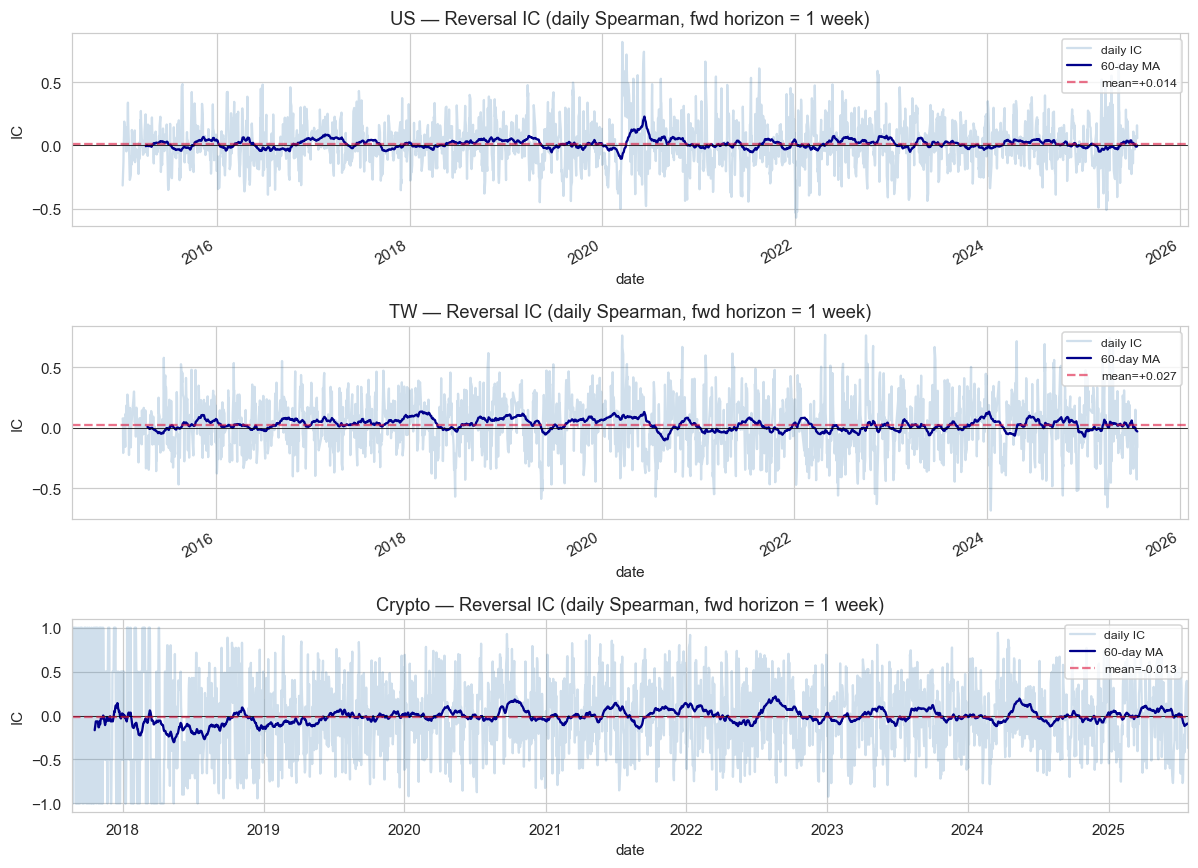

In [5]:
fig, axes = plt.subplots(3, 1, figsize=(11, 8), sharex=False)
for ax, (m, ic) in zip(axes, ic_series.items()):
    ic.plot(ax=ax, alpha=0.25, color="steelblue", label="daily IC")
    ic.rolling(60).mean().plot(ax=ax, color="darkblue", label="60-day MA")
    ax.axhline(0, color="black", lw=0.5)
    ax.axhline(ic.mean(), color="crimson", ls="--", alpha=0.6, label=f"mean={ic.mean():+.3f}")
    ax.set_title(f"{m} — Reversal IC (daily Spearman, fwd horizon = 1 week)")
    ax.set_ylabel("IC")
    ax.legend(loc="upper right", fontsize=8)
plt.tight_layout()
plt.savefig("../reports/figures/02_reversal_ic.png", dpi=130, bbox_inches="tight")
plt.show()

## 4. Quintile returns (weekly rebalance)

In [6]:
qret_by_market = {}
for m, info in markets.items():
    rb = resample_to_last(info["close"].index, REBALANCE)
    fwd = forward_return(info["close"], FWD_HORIZON)
    qret_by_market[m] = quantile_returns(
        info["signal"].reindex(rb), fwd.reindex(rb), n_quantiles=5
    ).mean()

qret_table = pd.DataFrame(qret_by_market).T
qret_table.columns = [f"Q{q}" for q in qret_table.columns]
qret_table["LS (Q5-Q1)"] = qret_table["Q5"] - qret_table["Q1"]
(qret_table * 100).round(3)

,Q1,Q2,Q3,Q4,Q5,LS (Q5-Q1)
US,0.277,0.294,0.310,0.330,0.449,0.172
TW,0.441,0.396,0.284,0.206,0.482,0.040
Crypto,1.570,0.828,1.101,0.042,0.117,-1.453


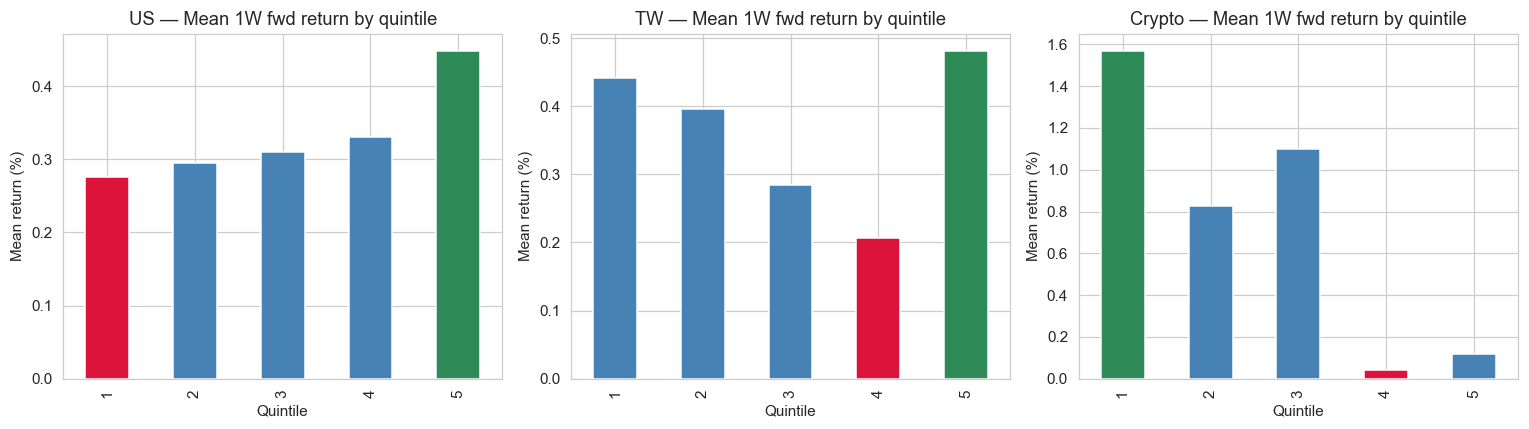

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, (m, qret) in zip(axes, qret_by_market.items()):
    colors = ["crimson" if q == qret.idxmin() else
              "seagreen" if q == qret.idxmax() else
              "steelblue" for q in qret.index]
    qret.mul(100).plot(kind="bar", ax=ax, color=colors)
    ax.set_title(f"{m} — Mean 1W fwd return by quintile")
    ax.set_xlabel("Quintile")
    ax.set_ylabel("Mean return (%)")
    ax.axhline(0, color="black", lw=0.5)
plt.tight_layout()
plt.savefig("../reports/figures/02_reversal_quintiles.png", dpi=130, bbox_inches="tight")
plt.show()

## 5. Long-short backtest — gross vs net

For reversal, **the story is in the cost drag**. Same weights, two engines:
one with zero costs, one with the realistic market-specific model.

In [8]:
def run_backtest(info, cost_model):
    weights = signal_to_weights(
        info["signal"].dropna(how="all"),
        n_quantiles=5, long_short=True, rebalance=REBALANCE,
    )
    engine = BacktestEngine(info["prices"], cost_model=cost_model)
    return engine.run(weights)

results_net = {m: run_backtest(info, info["costs"]) for m, info in markets.items()}
results_gross = {m: run_backtest(info, CostModel()) for m, info in markets.items()}

def perf_row(m, res, label):
    r = res.returns
    return {
        "market":       m,
        "variant":      label,
        "ann_ret":      annualized_return(r),
        "sharpe":       sharpe(r),
        "max_dd":       max_drawdown(r),
        "total_cost":   res.costs.sum(),
        "avg_turnover": res.turnover.mean(),
    }

rows = []
for m in markets:
    rows.append(perf_row(m, results_gross[m], "gross"))
    rows.append(perf_row(m, results_net[m],   "net"))

perf = pd.DataFrame(rows).set_index(["market", "variant"])
perf.round(4)

ann_ret  sharpe  max_dd  total_cost  avg_turnover
market variant                                                   
US     gross     0.0854  0.5557 -0.4073      0.0000        0.3191
       net       0.0015  0.0956 -0.5025      0.8485        0.3191
TW     gross     0.0130  0.1651 -0.6218      0.0000        0.3143
       net      -0.2973 -1.6023 -0.9727      3.7185        0.3143
Crypto gross    -0.5563 -0.6661 -1.0000      0.0000        0.2032
       net      -0.5996 -0.8002 -1.0000      1.1804        0.2032

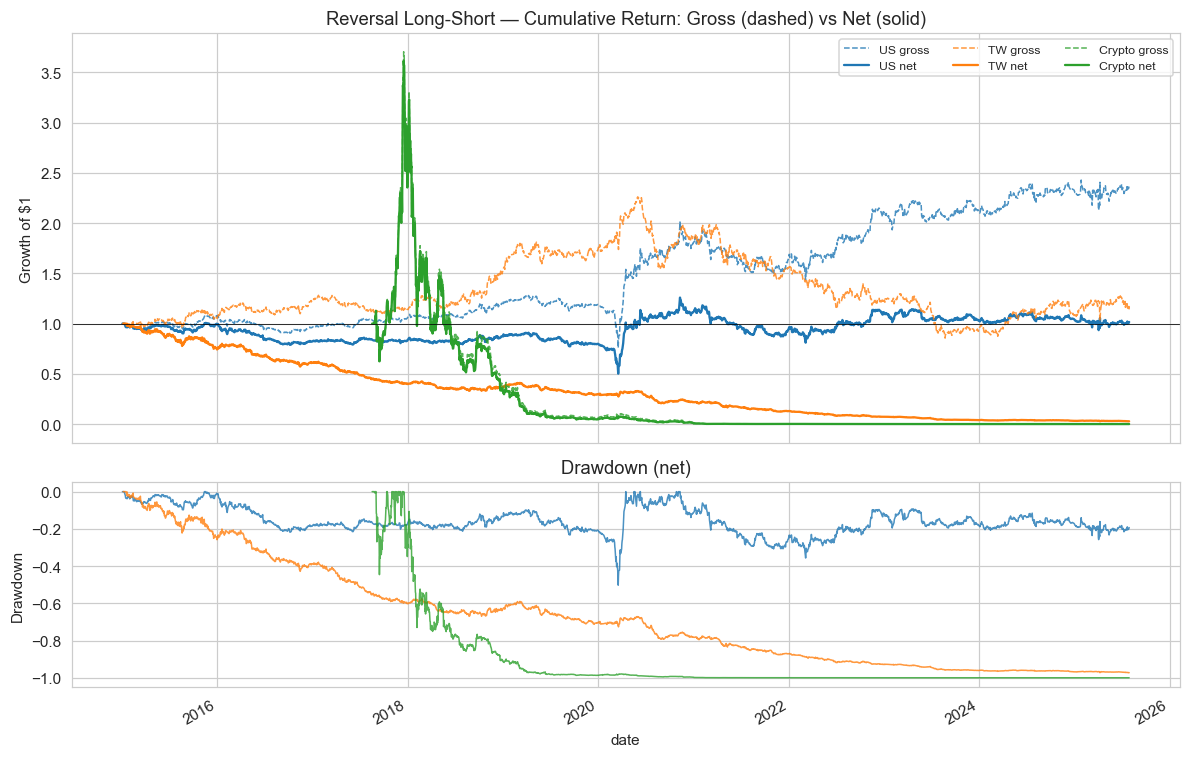

In [9]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 7), sharex=True,
                                gridspec_kw={"height_ratios": [2, 1]})
colors = {"US": "tab:blue", "TW": "tab:orange", "Crypto": "tab:green"}
for m in markets:
    (1 + results_gross[m].returns).cumprod().plot(
        ax=ax1, color=colors[m], ls="--", linewidth=1.0, alpha=0.8, label=f"{m} gross")
    (1 + results_net[m].returns).cumprod().plot(
        ax=ax1, color=colors[m], linewidth=1.5, label=f"{m} net")
    cum = (1 + results_net[m].returns).cumprod()
    dd = (cum - cum.cummax()) / cum.cummax()
    dd.plot(ax=ax2, color=colors[m], linewidth=1.0, alpha=0.8)

ax1.set_title("Reversal Long-Short — Cumulative Return: Gross (dashed) vs Net (solid)")
ax1.set_ylabel("Growth of $1"); ax1.legend(ncol=3, fontsize=8); ax1.axhline(1, color="black", lw=0.5)
ax2.set_title("Drawdown (net)")
ax2.set_ylabel("Drawdown")
plt.tight_layout()
plt.savefig("../reports/figures/02_reversal_gross_vs_net.png", dpi=130, bbox_inches="tight")
plt.show()

## 6. Turnover analysis

Weekly rebalance means turnover per period is very high. Below: how much of
the portfolio we trade each week, and where the cost bites hardest.

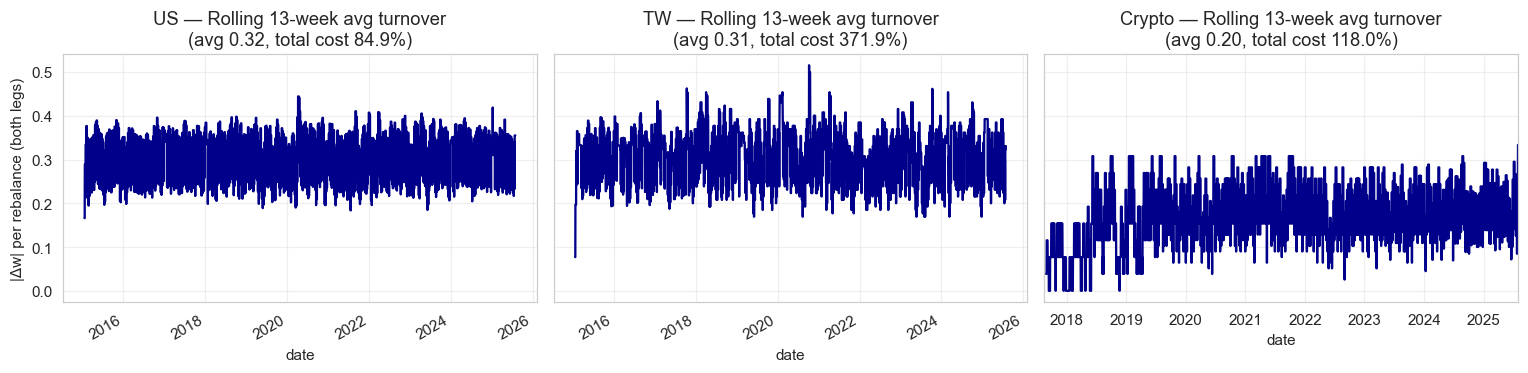


Per-year cost drag (% of capital):


,US,TW,Crypto
date,,,
2015,7.87,34.69,NaN
2016,7.92,35.31,NaN
2017,8.04,34.69,2.5
2018,8.02,36.94,10.6
2019,7.93,34.68,15.1
2020,8.22,37.08,15.6
2021,7.94,34.96,17.8
2022,8.05,34.18,15.166667
2023,8.06,33.49,15.633333


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.5), sharey=True)
for ax, (m, res) in zip(axes, results_net.items()):
    res.turnover.rolling(13).mean().plot(ax=ax, color="darkblue")
    ax.set_title(f"{m} — Rolling 13-week avg turnover\n(avg {res.turnover.mean():.2f}, "
                 f"total cost {res.costs.sum():.1%})")
    ax.set_ylabel("|Δw| per rebalance (both legs)")
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("../reports/figures/02_reversal_turnover.png", dpi=130, bbox_inches="tight")
plt.show()

# Per-year total cost as % of NAV
yearly_cost = pd.DataFrame({m: res.costs.groupby(res.costs.index.year).sum()
                             for m, res in results_net.items()})
print("\nPer-year cost drag (% of capital):")
(yearly_cost * 100).round(2)

## 7. Regime analysis

In [11]:
PERIODS = {
    "2015–2019":   ("2015-01-01", "2019-12-31"),
    "2020 COVID":  ("2020-01-01", "2020-12-31"),
    "2021–2022":   ("2021-01-01", "2022-12-31"),
    "2023–2025":   ("2023-01-01", "2025-07-31"),
}
rows = []
for m, res in results_net.items():
    for lbl, (s, e) in PERIODS.items():
        sub = res.returns.loc[s:e]
        if len(sub) < 10:
            continue
        rows.append({"market": m, "period": lbl,
                     "ann_ret": annualized_return(sub),
                     "sharpe":  sharpe(sub),
                     "max_dd":  max_drawdown(sub)})
regime = pd.DataFrame(rows).set_index(["market", "period"])
regime.round(3)

ann_ret  sharpe  max_dd
market period                             
US     2015–2019    -0.044  -0.388  -0.232
       2020 COVID    0.393   1.099  -0.371
       2021–2022    -0.001   0.091  -0.315
       2023–2025    -0.035  -0.132  -0.182
TW     2015–2019    -0.223  -1.436  -0.713
       2020 COVID   -0.271  -1.304  -0.370
       2021–2022    -0.436  -2.317  -0.680
       2023–2025    -0.325  -1.477  -0.624
Crypto 2015–2019    -0.587  -0.660  -0.987
       2020 COVID   -0.651  -1.085  -0.863
       2021–2022    -0.718  -0.953  -0.975
       2023–2025    -0.461  -0.702  -0.911

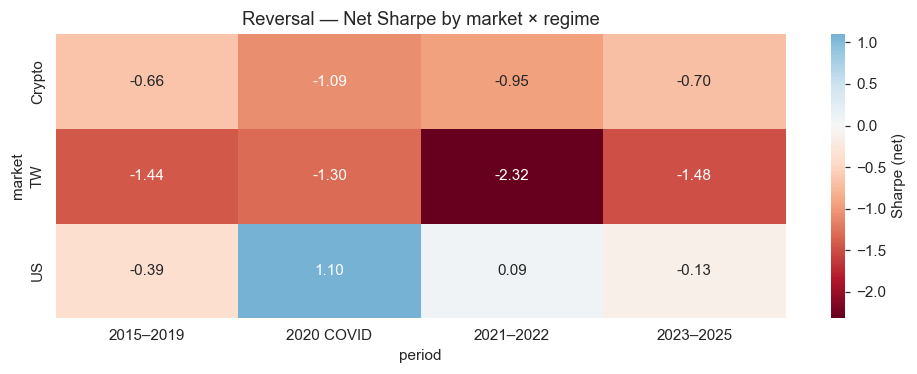

In [12]:
pivot = regime["sharpe"].unstack(level="period")
fig, ax = plt.subplots(figsize=(9, 3.5))
sns.heatmap(pivot, annot=True, fmt=".2f", cmap="RdBu", center=0, ax=ax,
            cbar_kws={"label": "Sharpe (net)"})
ax.set_title("Reversal — Net Sharpe by market × regime")
plt.tight_layout()
plt.savefig("../reports/figures/02_reversal_regime.png", dpi=130, bbox_inches="tight")
plt.show()

## 8. Takeaways

- **US reversal is a textbook "gross alpha eaten by costs"**: +0.56 Sharpe
  gross, +0.10 net. The signal demonstrably exists but is not
  retail-tradeable at the modelled cost.
- **TW weekly reversal is infeasible**. The 0.3% securities transaction
  tax on every sell, compounded over ~52 rebalances/year, produces a
  ~35%/yr cost drag that turns a mediocre gross signal (Sharpe +0.17)
  into a −1.60 Sharpe disaster net of costs.
- **Crypto is a momentum market at the weekly horizon** — reversal IC
  is negative in every regime (mean IC ≈ −0.013), so no cost model
  can save it.
- **Turnover** — average weekly turnover lands around the whole-portfolio
  level per rebalance; as an intuition check, that is ~52 complete
  rotations per year, which is the source of the TW cost drag.
- **Momentum vs reversal** (see 99_summary) — within each market their
  returns are near-uncorrelated (|ρ| < 0.1), confirming the two factors
  capture different horizons cleanly.